In [29]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction


#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Constants import *
#from spatial_functions import *

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['pdf.fonttype'] = 42

import warnings
warnings.simplefilter("ignore")

# Read

In [30]:
path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\iHSCA_20251110')
path

'/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/iHSCA_20251110'

In [3]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Mapping_with_Forsthuber'

In [4]:
os.listdir(path)

['VascularEndothelialCell_IntegratedAnnotation_2_20250531.h5ad',
 'SchwannCell_IntegratedAnnotation_2_20250531.h5ad',
 'MyeloidCell_IntegratedAnnotation_2_20250531.h5ad',
 'LymphaticEndothelialCell_IntegratedAnnotation_2_20250531.h5ad',
 'MastCell_Supported_IntegratedAnnotation_2_20250531.h5ad',
 'Lymphocyte_IntegratedAnnotation_2_20250531.h5ad',
 'Fibroblast_IntegratedAnnotation_2_20250531.h5ad',
 'LEC_20251124_IntegratedAnnotation_2_20250531.h5ad',
 'Keratinocyte_Karl_IntegratedAnnotation_2_20250531_Added_PCA.h5ad',
 'updated_adatas',
 'HF_IntegratedAnnotation_4_20260425.h5ad',
 'Glands_IntegratedAnnotation_4_20260425.h5ad',
 'HF_IntegratedAnnotation_4_20260505.h5ad',
 'Glands_IntegratedAnnotation_4_20260505.h5ad',
 'Melanocyte_IntegratedAnnotation_2_20251001.h5ad',
 'Keratinocyte_Hao_clustering_hvg.h5ad',
 'Keratinocyte_Karl_IntegratedAnnotation_2_20250531.h5ad',
 'MuralCell_IntegratedAnnotation_2_20250531.h5ad',
 'HFGland_IntegratedAnnotation_3_20250603_20241209.h5ad',
 'UMAP_test_

In [5]:
fib_data = sc.read_h5ad(os.path.join(path, 'Fibroblast_IntegratedAnnotation_2_20250531.h5ad'))
fib_data

AnnData object with n_obs × n_vars = 67229 × 75464
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Refere

In [6]:
caf_path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\SCSEA\data')
caf_data = sc.read_h5ad(os.path.join(caf_path, 'Beate_adata.h5ad'))
caf_data

AnnData object with n_obs × n_vars = 4824 × 26160
    obs: 'institute', 'study_PI', 'study_ID', 'study_name', 'publication_ID', 'repository_ID', 'experiment_ID', 'author_batch_notes', 'organism_ontology_term_id', 'donor_id', 'sex', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'development_stage_ontology_term_id', 'subject_type', 'subject_developmental_state', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_source', 'sample_collection_method', 'tissue_type', 'tissue_free_text', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'sample_collection_site', 'sample_cultured', 'sequencing_type', 'sample_collection_year', 'sample_colle

In [7]:
caf_data.obs['author_cell_type_1']=='Fibroblasts'

058_A18    False
058_A20    False
058_A21     True
058_A14    False
058_A19     True
           ...  
428_P18    False
428_P21    False
428_P19    False
428_P22    False
428_P20    False
Name: author_cell_type_1, Length: 4824, dtype: bool

In [8]:
shared_genes = fib_data.var_names.intersection(caf_data.var_names)
len(shared_genes)

25587

In [9]:
biomart_df = pd.read_csv('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/sensible_gene_df.csv', index_col = 0)
whitelist = biomart_df['external_gene_name'].values
biomart_df.head()
len(shared_genes.intersection(whitelist))
#don't filter based on whitelist yet

23676

In [10]:
rename_to_first = {
    "study_ID": "StudyID",
    "experiment_ID": "ExperimentID",
    "donor_id": "DonorID",
    "sex": "Sex",
    "ethnicity_1": "Ethnicity1",
    "ethnicity_2": "Ethnicity2",
    "ethnicity_details": "EthnicityDetail",
    "age_years": "Age",
    "subject_type": "SubjectType",
    "sample_id": "SampleID",
    "tissue_type": "Tissue",
    "sampled_site_condition": "SampledSiteCondition",
    "anatomical_region_level_1": "AnatomicalRegionLevel1",
    "anatomical_region_level_2": "AnatomicalRegionLevel2",
    "anatomical_region_level_3": "AnatomicalRegionLevel3",
    "sample_cultured": "SampleCultured",
    "protocol_tissue_dissociation": "ProtocolTissueDissociation",
    "library_platform": "LibraryPlatform",
    "sequenced_fragment": "StrandSequence",
    "sequencing_platform": "SequencingPlatform",
    "reference_genome": "ReferenceGenome",
    "author_cell_type_1": "OriginalAnnotation",
}

rename_existing = {
    old: new
    for old, new in rename_to_first.items()
    if old in caf_data.obs.columns and new not in caf_data.obs.columns
}

caf_data.obs = caf_data.obs.rename(columns=rename_existing)

In [11]:
matched = sorted(rename_existing.items())
unmatched_adata2 = sorted(set(caf_data.obs.columns) - set(fib_data.obs.columns))

print("Renamed:")
for old, new in matched:
    print(f"{old} -> {new}")

print("\nStill unique to adata2:")
print(unmatched_adata2)

Renamed:
age_years -> Age
anatomical_region_level_1 -> AnatomicalRegionLevel1
anatomical_region_level_2 -> AnatomicalRegionLevel2
anatomical_region_level_3 -> AnatomicalRegionLevel3
author_cell_type_1 -> OriginalAnnotation
donor_id -> DonorID
ethnicity_1 -> Ethnicity1
ethnicity_2 -> Ethnicity2
ethnicity_details -> EthnicityDetail
experiment_ID -> ExperimentID
library_platform -> LibraryPlatform
protocol_tissue_dissociation -> ProtocolTissueDissociation
reference_genome -> ReferenceGenome
sample_cultured -> SampleCultured
sample_id -> SampleID
sampled_site_condition -> SampledSiteCondition
sequenced_fragment -> StrandSequence
sequencing_platform -> SequencingPlatform
sex -> Sex
study_ID -> StudyID
subject_type -> SubjectType
tissue_type -> Tissue

Still unique to adata2:
['alignment_software', 'author_batch_notes', 'author_cell_type_2', 'author_cell_type_3', 'author_cell_type_4', 'author_cell_type_5', 'author_cell_type_6', 'autoimmune_component', 'bmi', 'cell_enrichment', 'cell_number_l

# Combine data

In [12]:
adata = sc.concat([fib_data[:, shared_genes], caf_data[:, shared_genes][caf_data.obs['OriginalAnnotation'].isin(['Fibroblasts', 'Pericytes_vSMCs'])]], join = 'outer')

In [13]:
adata.obs['Source'] = np.where(adata.obs['StudyID'] == 'Forsthuber_Lichtenberger_bioRxiv_2023', 'Forsthuber', 'iHSCA')

## Process

In [14]:
def process_data(adata):
    adata.layers['raw_counts'] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    adata.layers['normalized'] = adata.X.copy()
    sc.pp.scale(adata, zero_center = True)
    adata.layers['scaled'] = adata.X.copy()
    return adata

adata = sc.concat([process_data(adata[adata.obs['StudyID']==study]) for study in adata.obs['StudyID'].unique()])

adata

AnnData object with n_obs × n_vars = 69468 × 25587
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Refere

In [50]:
adata

AnnData object with n_obs × n_vars = 69468 × 25587
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Refere

In [16]:
#Fix missing sequencing platform
caf_data.obs['SequencingPlatform'] = caf_data.obs['SequencingPlatform'].fillna('Illumina HiSeq 2000')
adata.obs['SequencingPlatform'] = adata.obs['SequencingPlatform'].astype('object').fillna(caf_data.obs['SequencingPlatform'])

In [17]:
batch_cols = ['SampleID', 'DonorID', 'SequencingPlatform', 'StudyID']
adata.obs['combined_batch'] = adata.obs[batch_cols].astype(str).agg('_'.join, axis=1)
adata.obs['combined_batch'] = adata.obs['combined_batch'].astype('category')

In [18]:
threshold = 25

adata.obs['study_donor_fallback'] = adata.obs['StudyID']

batch_counts = adata.obs['combined_batch'].value_counts()
small_batches = batch_counts[batch_counts < threshold].index

adata.obs['robust_batch'] = np.where(
    adata.obs['combined_batch'].isin(small_batches),
    adata.obs['study_donor_fallback'].astype(str)+'_combined_donors',
    adata.obs['combined_batch']
)

In [19]:
adata.obs['robust_batch'].value_counts().tail(40)

robust_batch
Hughes_Shalek_Immunity_2020___Normal3_Hughes_Shalek_Immunity_2020___Normal3_Illumina NextSeq 500_Hughes_Shalek_Immunity_2020                                                                              158
BCC III_BCC III_Illumina HiSeq 2000_Forsthuber_Lichtenberger_bioRxiv_2023                                                                                                                                 147
Healthy IV_Healthy IV_Illumina HiSeq 2000_Forsthuber_Lichtenberger_bioRxiv_2023                                                                                                                           146
Mel II_Mel II_Illumina HiSeq 2000_Forsthuber_Lichtenberger_bioRxiv_2023                                                                                                                                   144
Tabib_Lafyatis_NatureCommunications_2021___SC34_Tabib_Lafyatis_NatureCommunications_2021___SC34_Illumina NextSeq 500_Tabib_Lafyatis_NatureCommunications_2021      

In [20]:
sc.pp.highly_variable_genes(adata, batch_key = 'robust_batch', n_top_genes = 2000, layer = 'raw_counts', flavor='seurat_v3')

## Integrate

In [21]:
key = 'combined_batch_harmony'
sc.pp.pca(adata, use_highly_variable=True, layer='scaled')
sce.pp.harmony_integrate(adata, key = 'robust_batch', adjusted_basis = 'X_pca_harmony_combined')
#bbknn.bbknn(adata, batch_key = 'LibraryPlatform', use_rep = 'harmonyDonorID', key_added = key)

sc.pp.neighbors(adata, use_rep = 'X_pca_harmony_combined', key_added='neighbors_combined_batch')

2026-05-22 13:39:06,591 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-22 13:39:13,420 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-22 13:39:13,723 - harmonypy - INFO - Iteration 1 of 10
2026-05-22 13:39:49,551 - harmonypy - INFO - Iteration 2 of 10
2026-05-22 13:40:27,469 - harmonypy - INFO - Iteration 3 of 10
2026-05-22 13:41:23,317 - harmonypy - INFO - Iteration 4 of 10
2026-05-22 13:42:14,753 - harmonypy - INFO - Iteration 5 of 10
2026-05-22 13:43:03,108 - harmonypy - INFO - Iteration 6 of 10
2026-05-22 13:43:28,411 - harmonypy - INFO - Iteration 7 of 10
2026-05-22 13:43:50,785 - harmonypy - INFO - Iteration 8 of 10
2026-05-22 13:44:10,529 - harmonypy - INFO - Converged after 8 iterations


In [22]:
sc.tl.umap(adata, key_added = 'umap', neighbors_key = 'neighbors_combined_batch')

<Axes: title={'center': 'StudyID'}, xlabel='UMAP1', ylabel='UMAP2'>

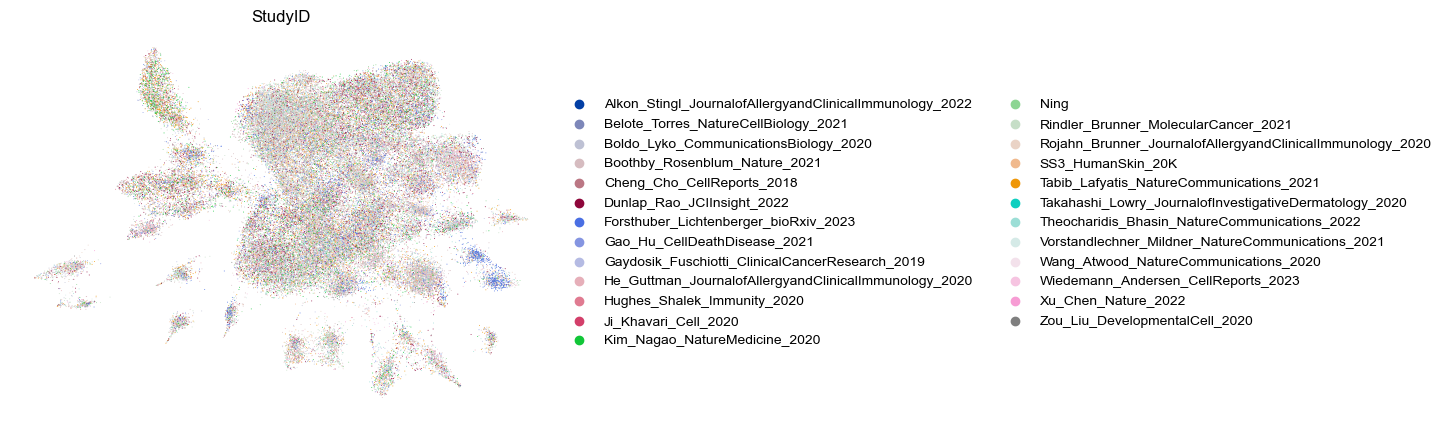

In [23]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False, color = 'StudyID')

### Fig S6m

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

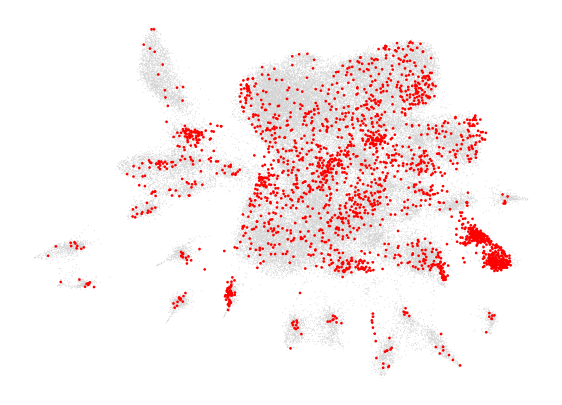

In [25]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False)
sc.pl.embedding(adata[adata.obs['Source']=='Forsthuber'], basis = 'umap', color = 'Source', frameon = False, ax = ax, show = False, palette = {'Forsthuber': 'red'}, s = 15, title = '', legend_loc = None)

fig.savefig(os.path.join(fig_path, 'UMAP_integrated_Forsthuber_cells.png'), bbox_inches = 'tight', dpi = 600)

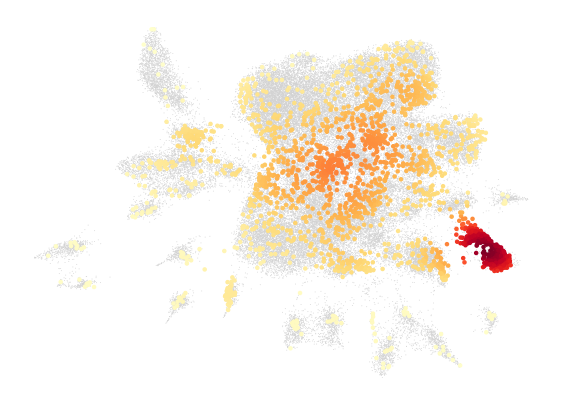

In [211]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False)
x, y = zip(*adata[adata.obs['Source']=='Forsthuber'].obsm['umap'])
z = calc_density(x, y)
ax.scatter(x = x, y = y, c = z, cmap = 'YlOrRd', s = 5)

fig.savefig(os.path.join(fig_path, 'UMAP_integrated_Forsthuber_cells_density.png'), bbox_inches = 'tight', dpi = 600)

### Fig S6i

In [212]:
cmap = {
    "vSMC": "tomato",
    "RGS5+ cells": "slateblue",
    "ucCAF": "sienna",
    "iCAF": "midnightblue",
    "mCAF": "darkviolet",
    "pFIB": "forestgreen",
    "rFIB": "limegreen",
}

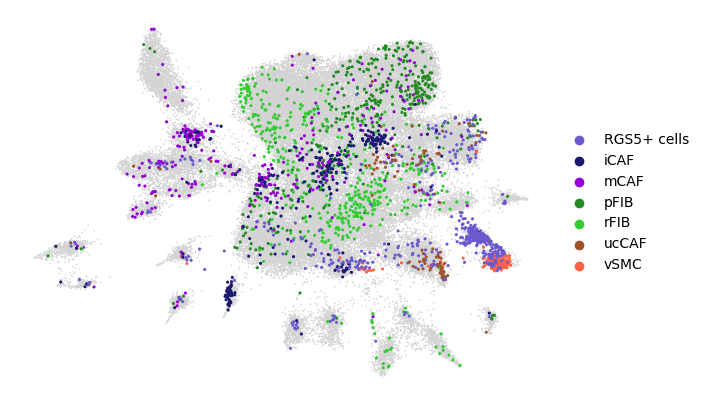

In [271]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False, s = 5)
sc.pl.embedding(adata[adata.obs['Source']=='Forsthuber'], basis = 'umap', color = 'author_cell_type_3', frameon = False, ax = ax, show = False, s = 20, title = '', palette = cmap)

fig.savefig(os.path.join(fig_path, 'UMAP_integrated_Forsthuber_clusters.png'), bbox_inches = 'tight', dpi = 1200)

### Fig S6l

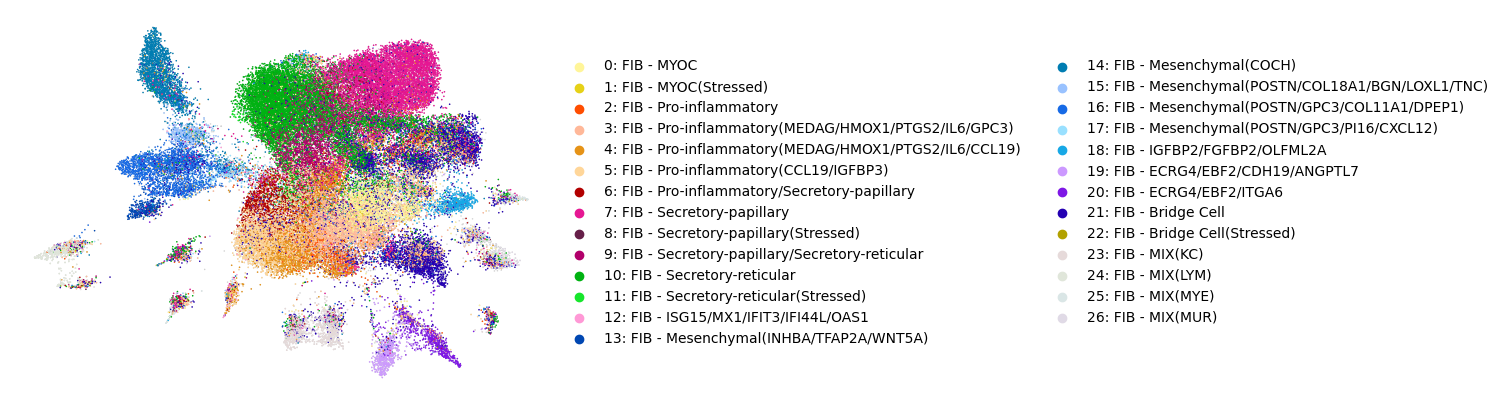

In [275]:
fib_cmap = {cl: fib_colormap[cl.split(':')[0]] for cl in adata.obs['Annotation_Level_2_FULL'].unique() if isinstance(cl, str)}
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False, s = 5)
sc.pl.embedding(adata[adata.obs['Source']!='Forsthuber'], basis = 'umap', color = 'Annotation_Level_2_FULL', frameon = False, ax = ax, show = False, palette = fib_cmap, s = 5, title = '')

fig.savefig(os.path.join(fig_path, 'UMAP_integrated_Forsthuber_iHSCA_clusters.png'), bbox_inches = 'tight', dpi = 1200)

### Fig S6j

In [26]:
resolutions = [0.1, 0.2, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3,]
for res in resolutions:
    print(res)
    clear_output(wait = True)
    sc.tl.leiden(adata, key_added = f'leiden_harmony_combined_{res}', resolution = res, neighbors_key = 'neighbors_combined_batch')

3


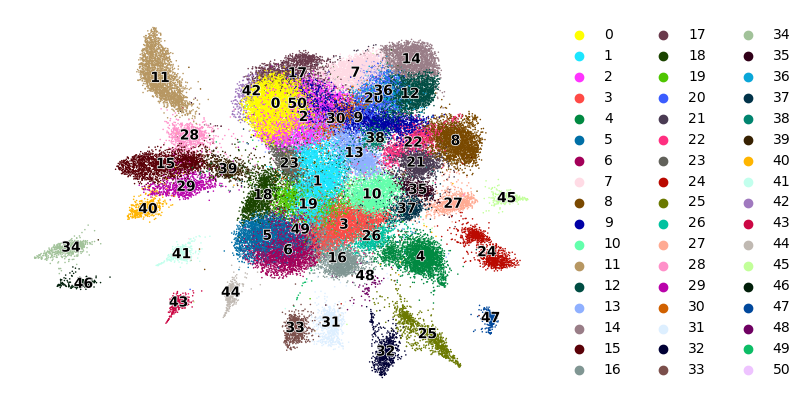

In [274]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False, color = 'leiden_harmony_combined_3', s = 5)
sc.pl.embedding(adata, basis = 'umap', frameon = False, ax = ax, show = False, color = 'leiden_harmony_combined_3', s = 0, legend_loc = 'on data', legend_fontoutline = True, title = '')

fig.savefig(os.path.join(fig_path, 'UMAP_integrated_leiden_3.png'), bbox_inches = 'tight', dpi = 1200)

### Fig S6k

[None, None]

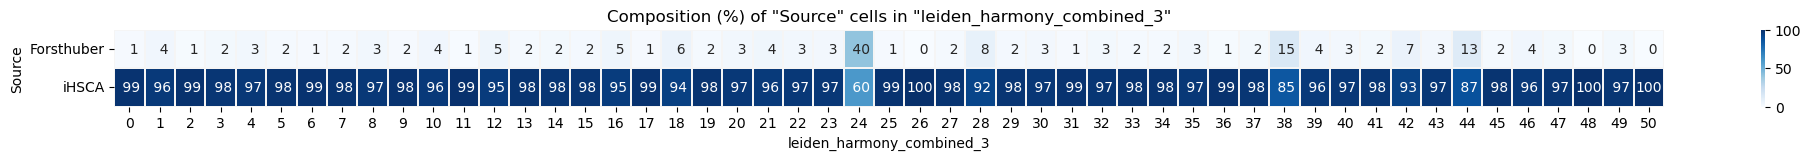

In [260]:
fig, ax = plt.subplots(figsize = (25, 1))
plot_group_composition_heatmap(adata.obs, groupby_name='leiden_harmony_combined_3', count_group_name='Source', cmap = 'Blues', ax = ax, fmt = '3.0f', transpose = True, lw = 0.05, linecolor = 'whitesmoke')
clear_output()
[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_leiden_3.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

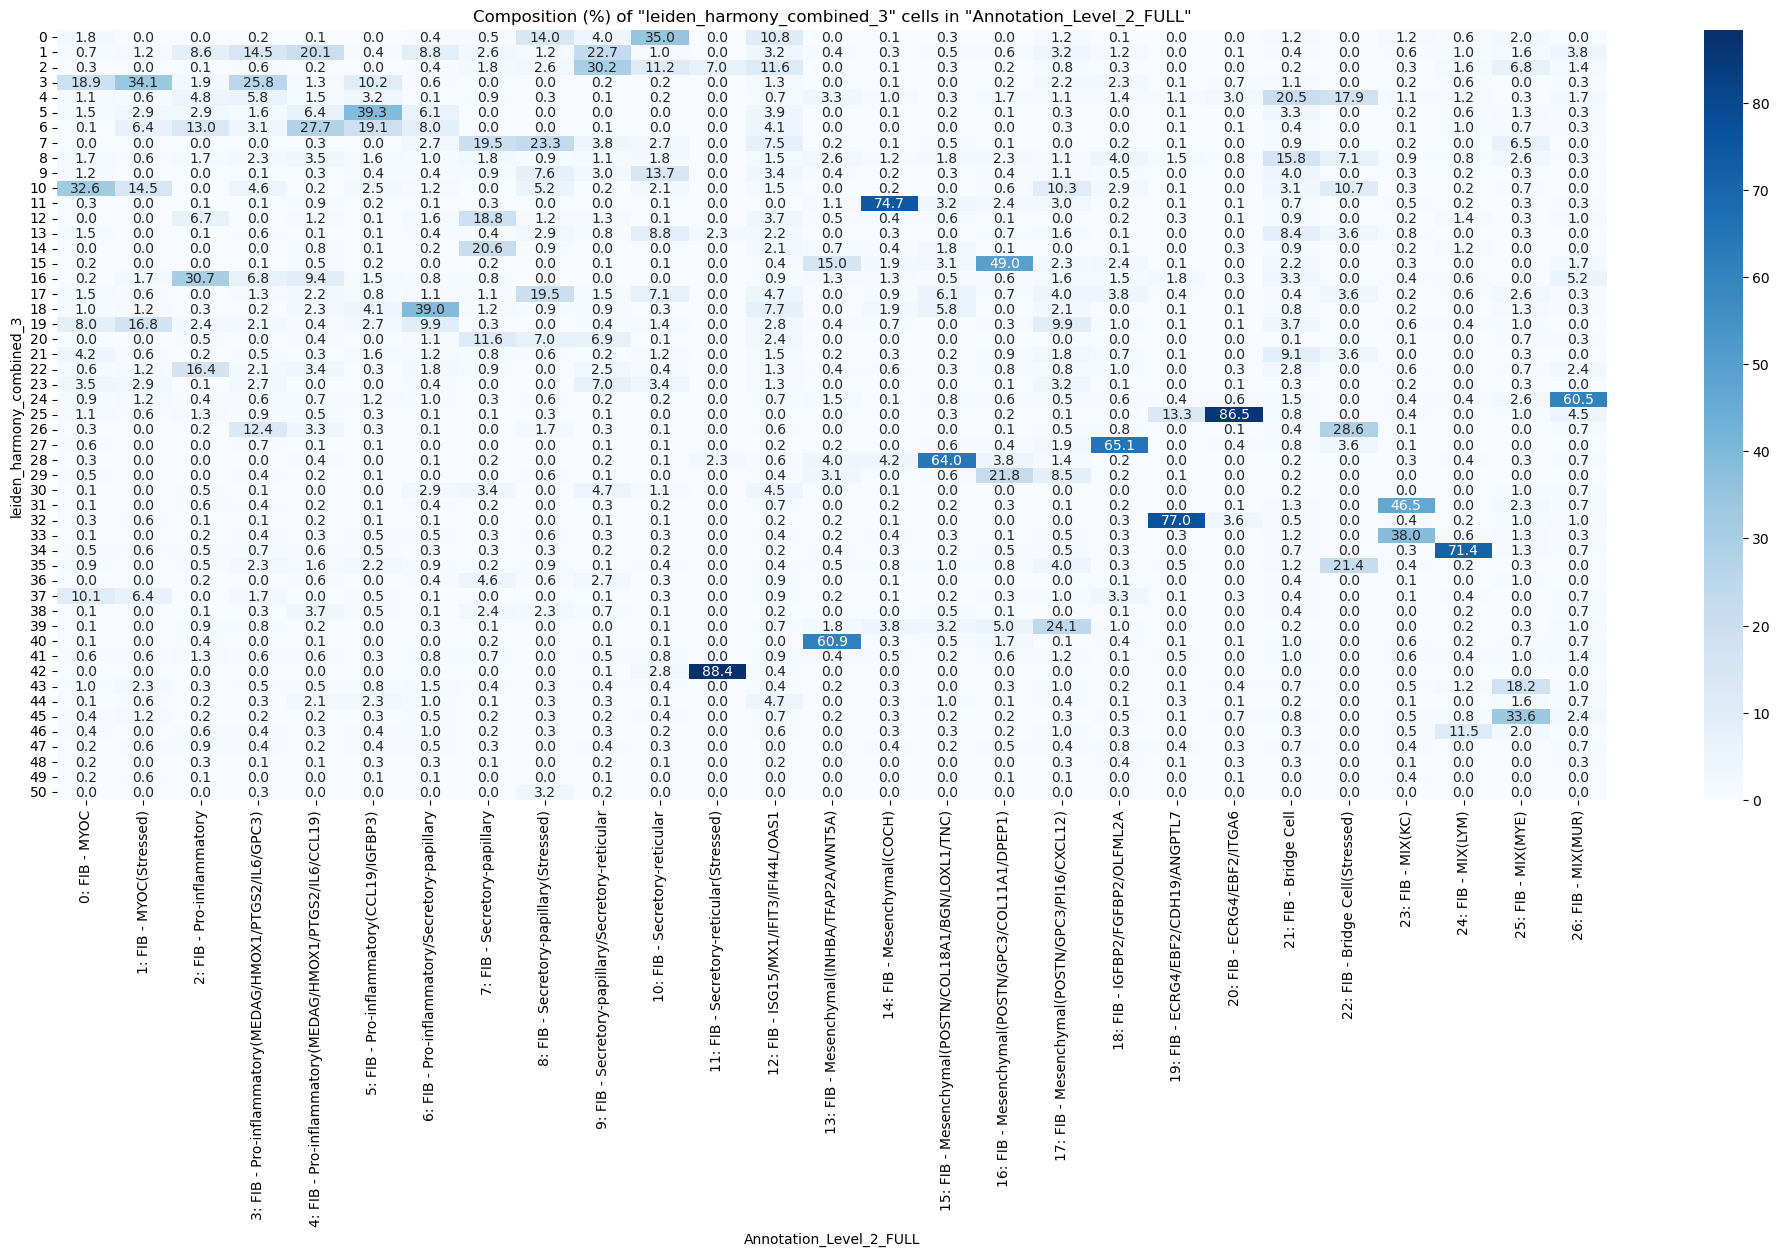

In [70]:
fig, ax = plt.subplots(figsize = (25, 10))
plot_group_composition_heatmap(adata.obs, count_group_name='leiden_harmony_combined_3', groupby_name='Annotation_Level_2_FULL', cmap = 'Blues', ax = ax, fmt = '3.1f', transpose = True)
clear_output()

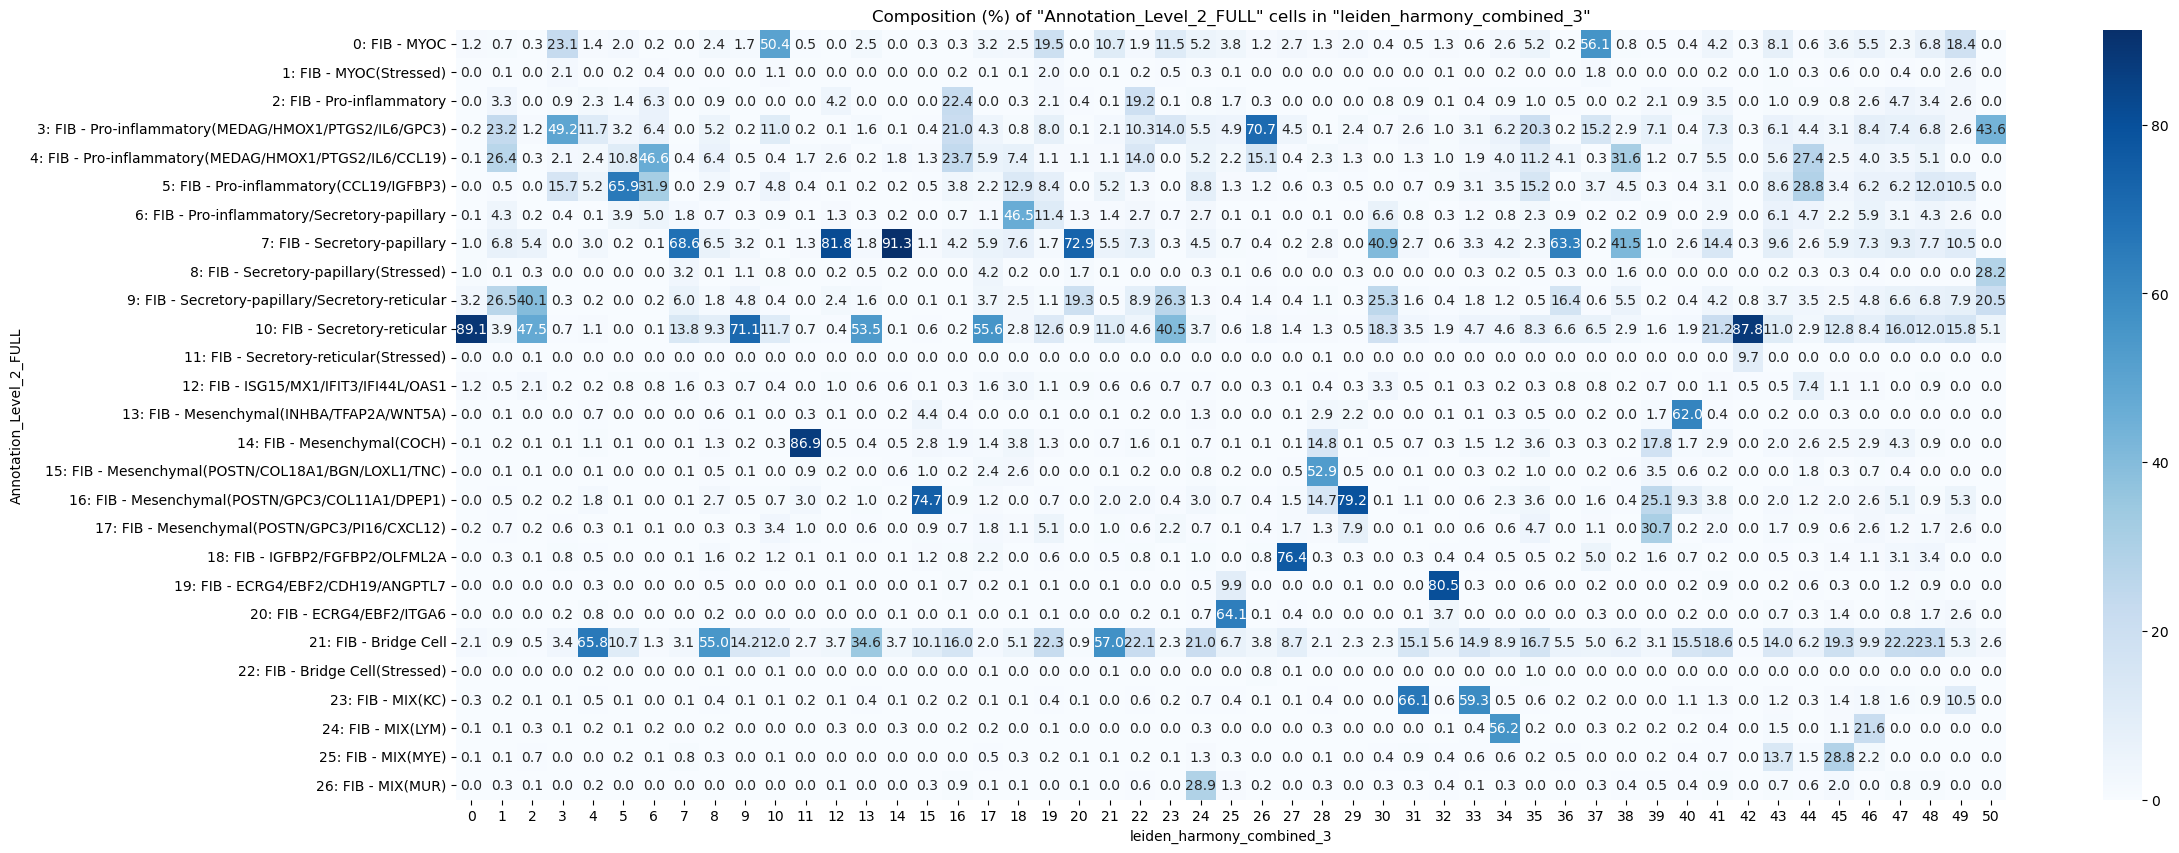

In [71]:
fig, ax = plt.subplots(figsize = (25, 10))
plot_group_composition_heatmap(adata.obs, groupby_name='leiden_harmony_combined_3', count_group_name='Annotation_Level_2_FULL', cmap = 'Blues', ax = ax, fmt = '3.1f', transpose = True)
clear_output()

# save

In [27]:
adata.write_h5ad('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/Forsthuber_Fibroblasts_iHSCA_integration.h5ad')

In [137]:
que_data.obs['leiden_harmony_combined_3'] = adata.obs.loc[que_data.obs_names, 'leiden_harmony_combined_3']

<Axes: title={'center': 'Annotation_Level_2_renumber'}, xlabel='UMAP_L21', ylabel='UMAP_L22'>

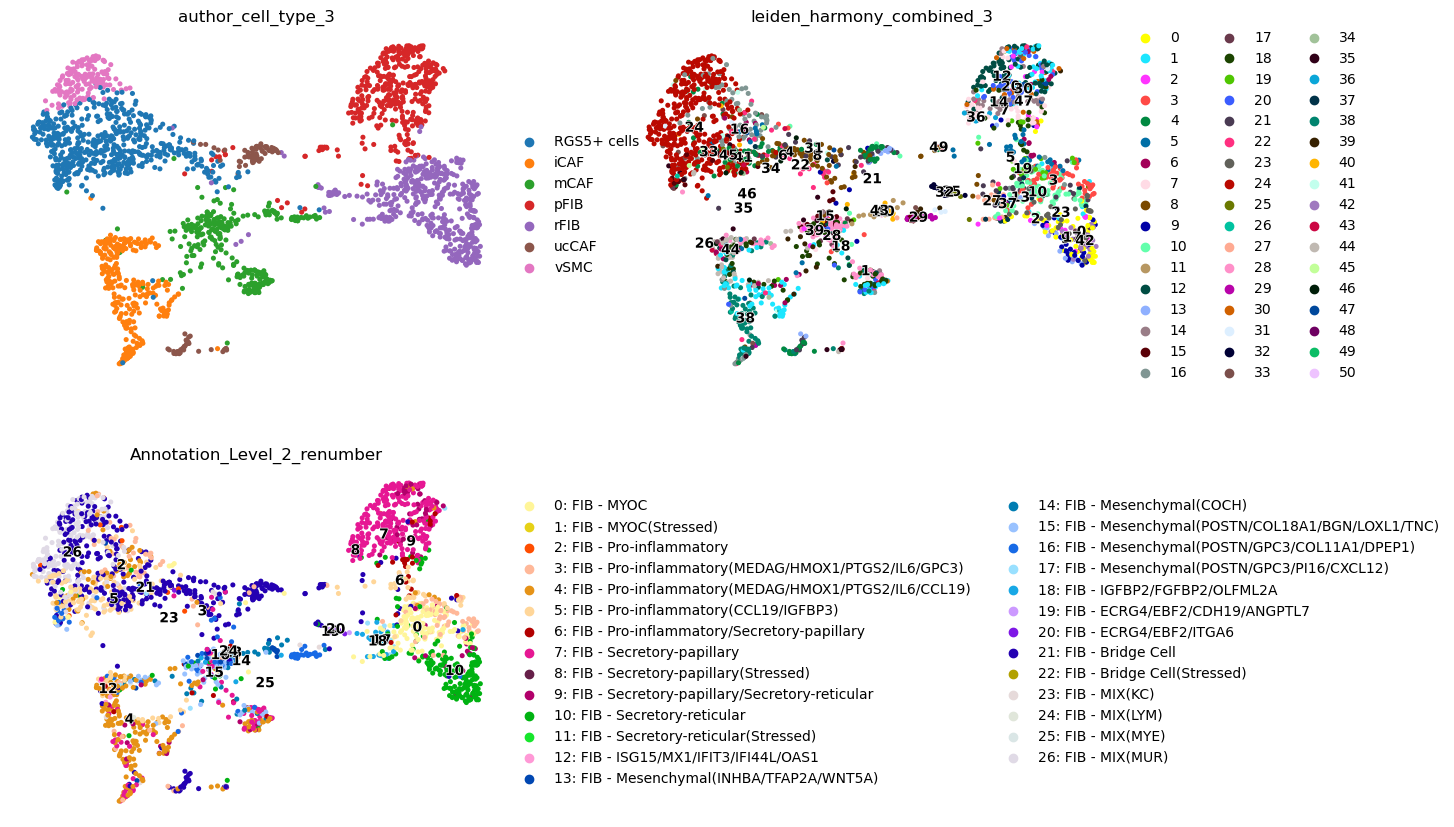

In [147]:
fig = sc.pl.embedding(que_data, basis = 'UMAP_L2', color = ['author_cell_type_3', 'leiden_harmony_combined_3', 'Annotation_Level_2_FULL'], frameon = False, return_fig=True, show = False, ncols = 2)
axes = fig.get_axes()
sc.pl.embedding(que_data, basis = 'UMAP_L2', color = 'leiden_harmony_combined_3', frameon = False, ax = axes[1], legend_loc = 'on data', s = 0, legend_fontoutline=True, show = False)
sc.pl.embedding(que_data, basis = 'UMAP_L2', color = 'Annotation_Level_2_renumber', frameon = False, ax = axes[-1], legend_loc = 'on data', s = 0, legend_fontoutline=True, show = False)

## Fig 6k

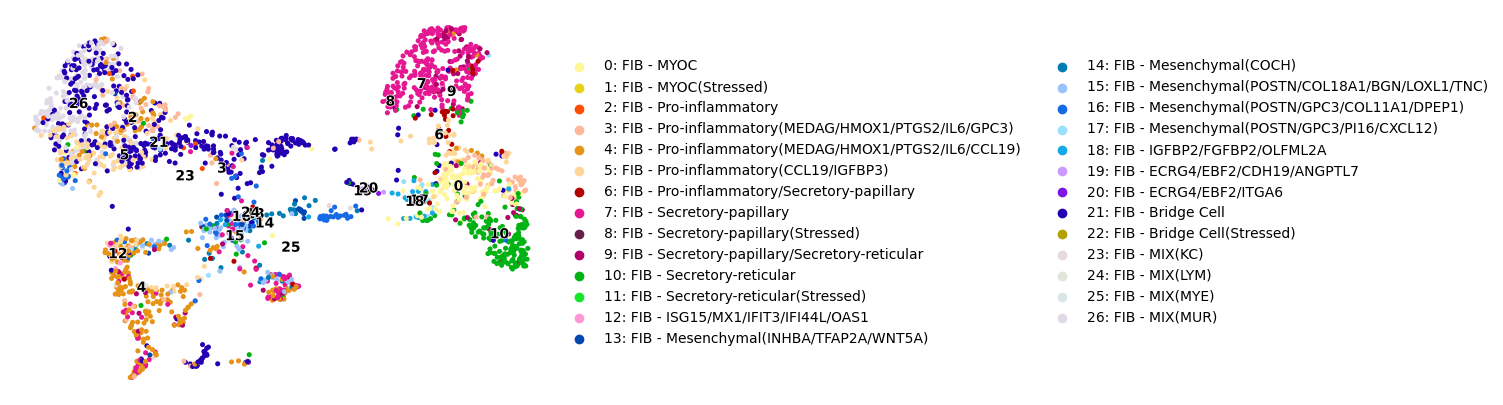

In [253]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(que_data, basis = 'UMAP_L2', frameon = False, ax = ax, show = False, color = 'Annotation_Level_2_FULL')
sc.pl.embedding(que_data, basis = 'UMAP_L2', frameon = False, ax = ax, show = False, color = 'Annotation_Level_2_renumber', s = 0, legend_loc = 'on data', legend_fontoutline=True, title = '')

fig.savefig(os.path.join(fig_path, 'UMAP_CAFs_knn_iHSCA_clusters.png'), bbox_inches = 'tight', dpi = 600)

## Fig 6j

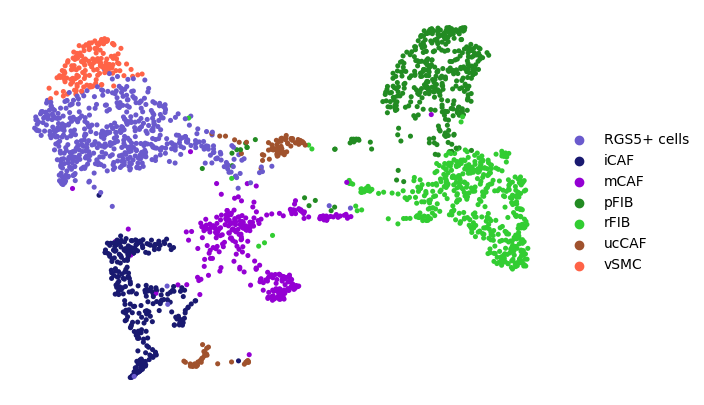

In [322]:
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.embedding(que_data, basis = 'UMAP_L2', frameon = False, ax = ax, show = False, color = 'author_cell_type_3', palette = cmap, title = '')
#sc.pl.embedding(que_data, basis = 'UMAP_L2', frameon = False, ax = ax, show = False, color = 'Annotation_Level_2_renumber', s = 0, legend_loc = 'on data', legend_fontoutline=True, title = '')

fig.savefig(os.path.join(fig_path, 'UMAP_CAF_clusters.png'), bbox_inches = 'tight', dpi = 600)

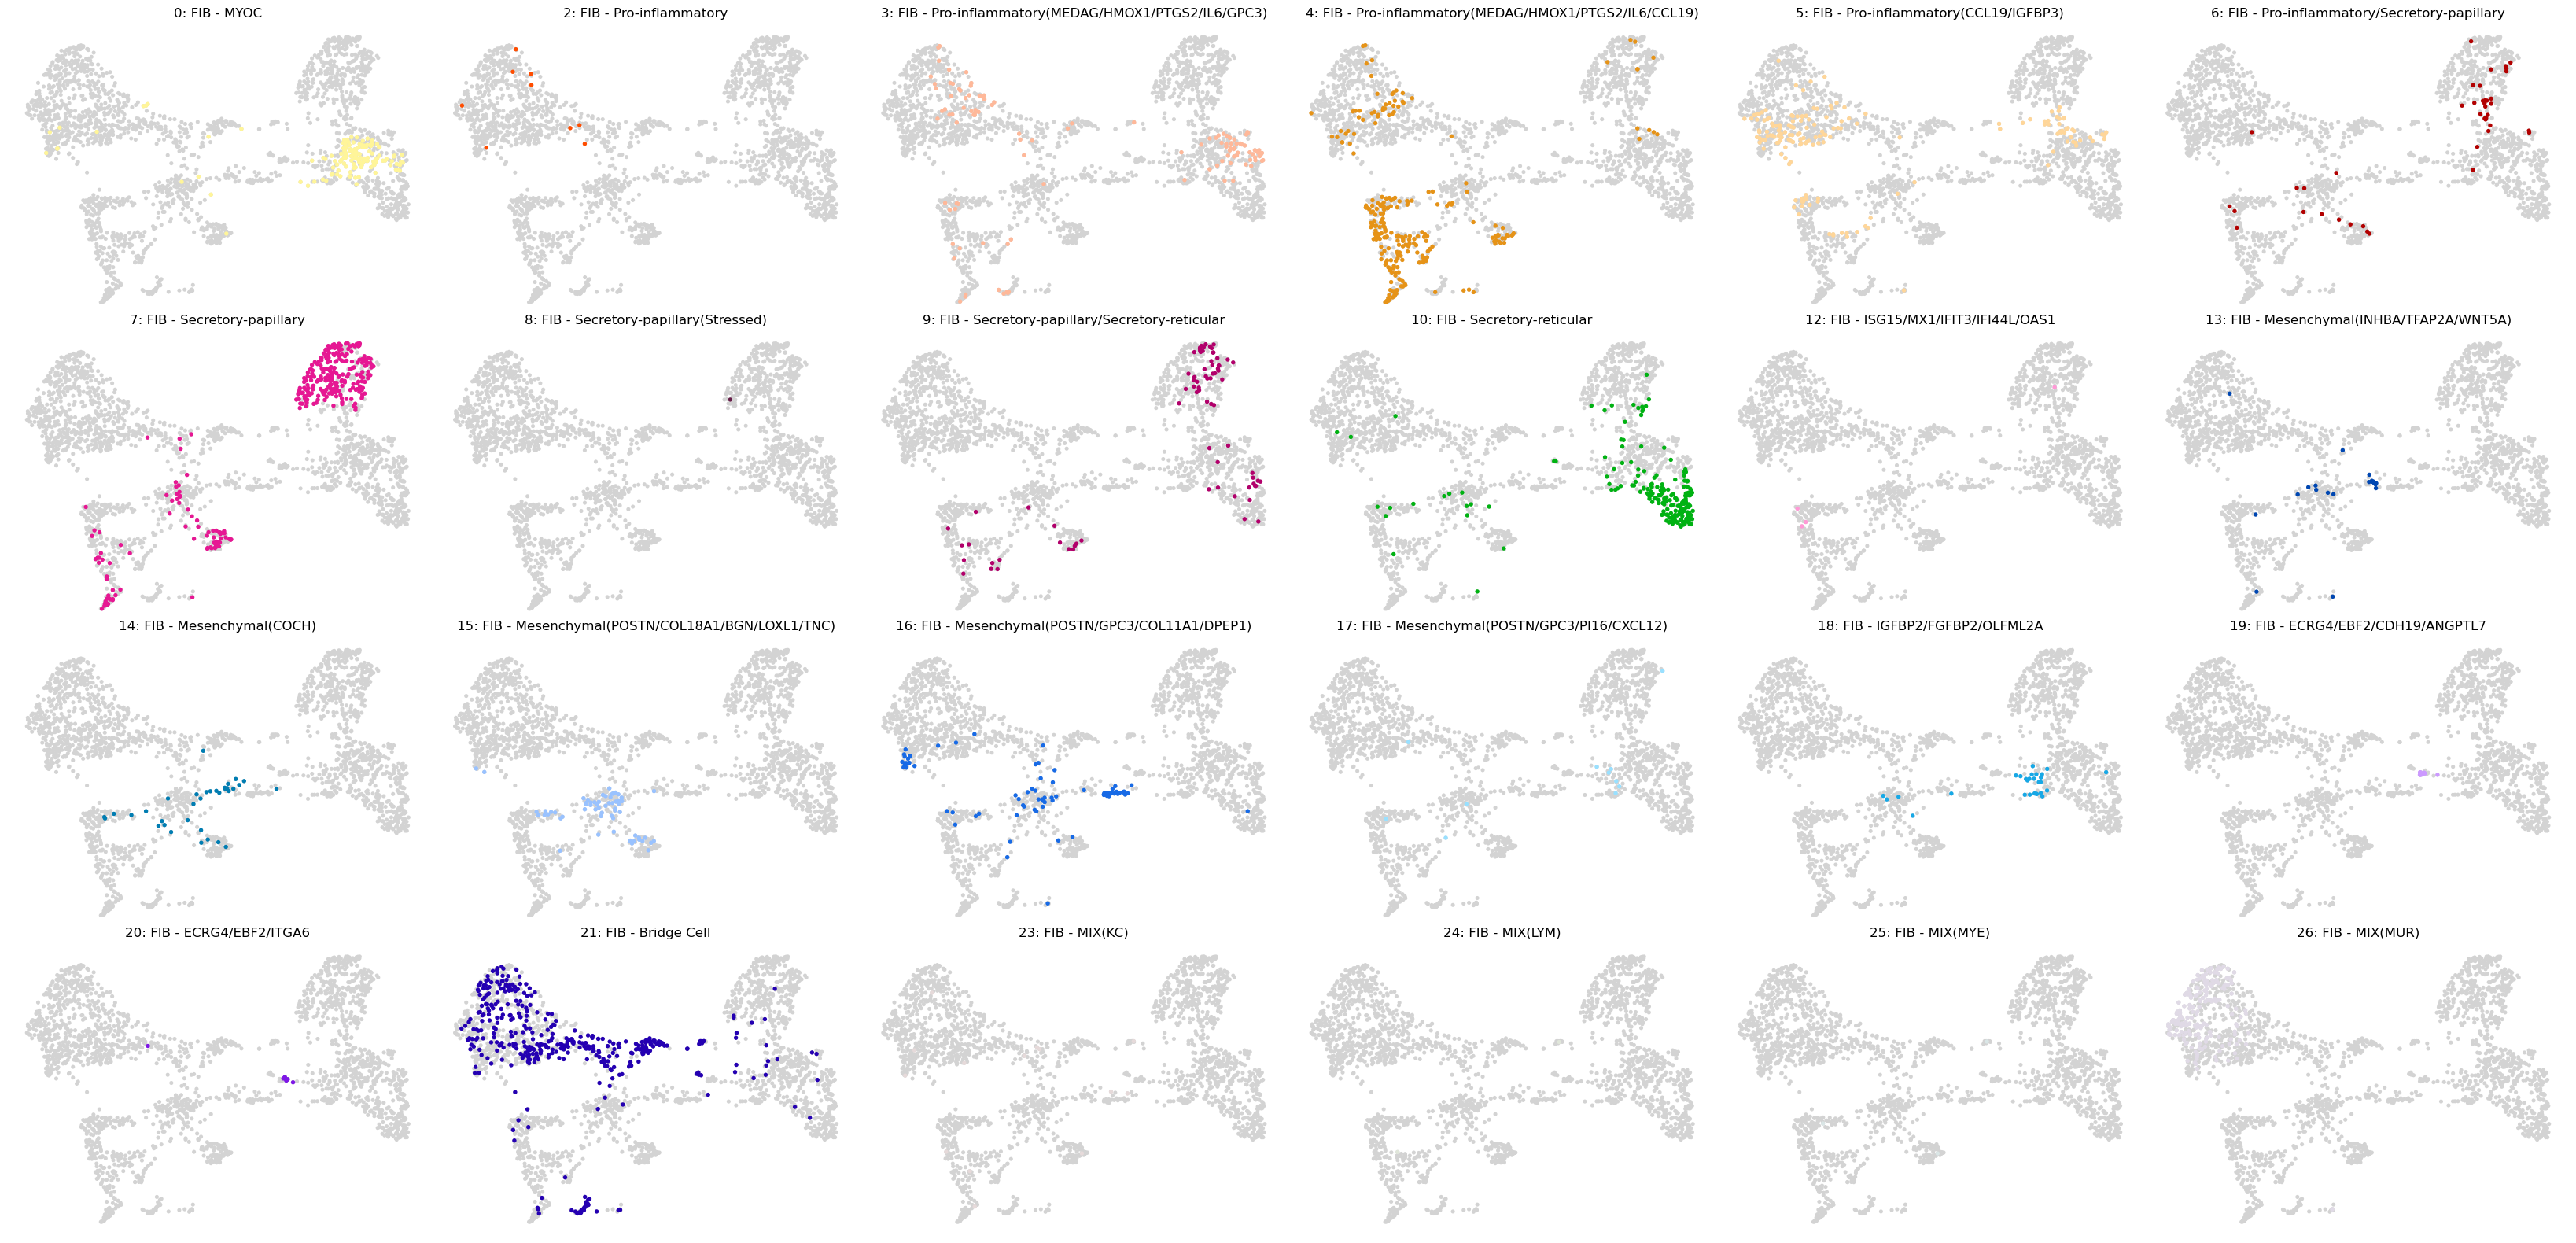

In [259]:
clusters = natsorted(que_data.obs['Annotation_Level_2_FULL'].unique())
fig, axes = initialize_subplots(len(clusters), ncols = 6, gridspec_kw = dict(wspace = 0.02, hspace = 0.05))

for ix, cl in enumerate(clusters):
    ax = axes.flatten()[ix]
    sc.pl.embedding(que_data, basis = 'UMAP_L2', frameon = False, show = False, ax = ax)
    sc.pl.embedding(que_data[que_data.obs['Annotation_Level_2_FULL']==cl], basis = 'UMAP_L2', color = 'Annotation_Level_2_FULL', frameon = False, show = False, ax = ax, title = cl, s = 60, palette = fib_cmap, legend_loc = None)
    
[ax.set_visible(False) for ax in axes.flatten()[ix+1:]]
clear_output()

fig.savefig(os.path.join(fig_path, 'UMAP_CAFs_knn_iHSCA_clusters_individual_plots.png'), bbox_inches = 'tight', dpi = 600)

# Save integration

In [156]:
que_data.write_h5ad('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/Forsthuber_Fibroblasts_integrated_to_iHSCA.h5ad')

# Load

In [ ]:
fib_data = sc.read_h5ad(os.path.join(path, 'Fibroblast_IntegratedAnnotation_2_20250531.h5ad'))
fib_data

In [6]:
que_data = sc.read_h5ad('/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/Forsthuber_Fibroblasts_integrated_to_iHSCA.h5ad')

In [7]:
que_data

AnnData object with n_obs × n_vars = 2239 × 25587
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Ambiguity', 'Exon', 'Intergenic', 'Intron', 'Unmapped', 'plateID', 'indices', 'WellID', 'donor', 'group', 'bodysite', 'nReads', 'rRNA', 'pct_exon', 'ProtocolTissueDissociation', 'PlateID', 'n_genes', 'pct_counts_rRNA', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'merge_by', 'S_score', 'G2M_score', 'phase', 'leiden_1_001', 'leiden_1_002', 'leiden_1_003', 'leiden_1_005', 'leiden_1_008', 'leiden_1_010', 'leiden_1_012', 'leiden_1_015', 'leiden_1_020', 'leiden_1_030', 'leiden_1_050', 'leiden_1_080', 'leiden_1_100', 'leiden_1_120', 'leiden_1_150', 'leiden_1_200', 'leiden_1_300', 'select', 'leiden_1', 'Y_X_ratio', 'percent.mt', 'Patient', '_UMAP1', '_UMAP2', '_tSNE1', '_tSNE2', 'DonorID_short', 'Age', 'Sex', 'Ethnicity1', 'SubjectType', 'SampleID', 'SampleType', 'SampledSiteCondition', 'Tissue', 'LibraryPlatform', 'StrandSequence', 'SequencingPlatform', 'Referen

In [15]:
cmap = {
    "vSMC": "tomato",
    "RGS5+ cells": "slateblue",
    "ucCAF": "sienna",
    "iCAF": "midnightblue",
    "mCAF": "darkviolet",
    "pFIB": "forestgreen",
    "rFIB": "limegreen",
}

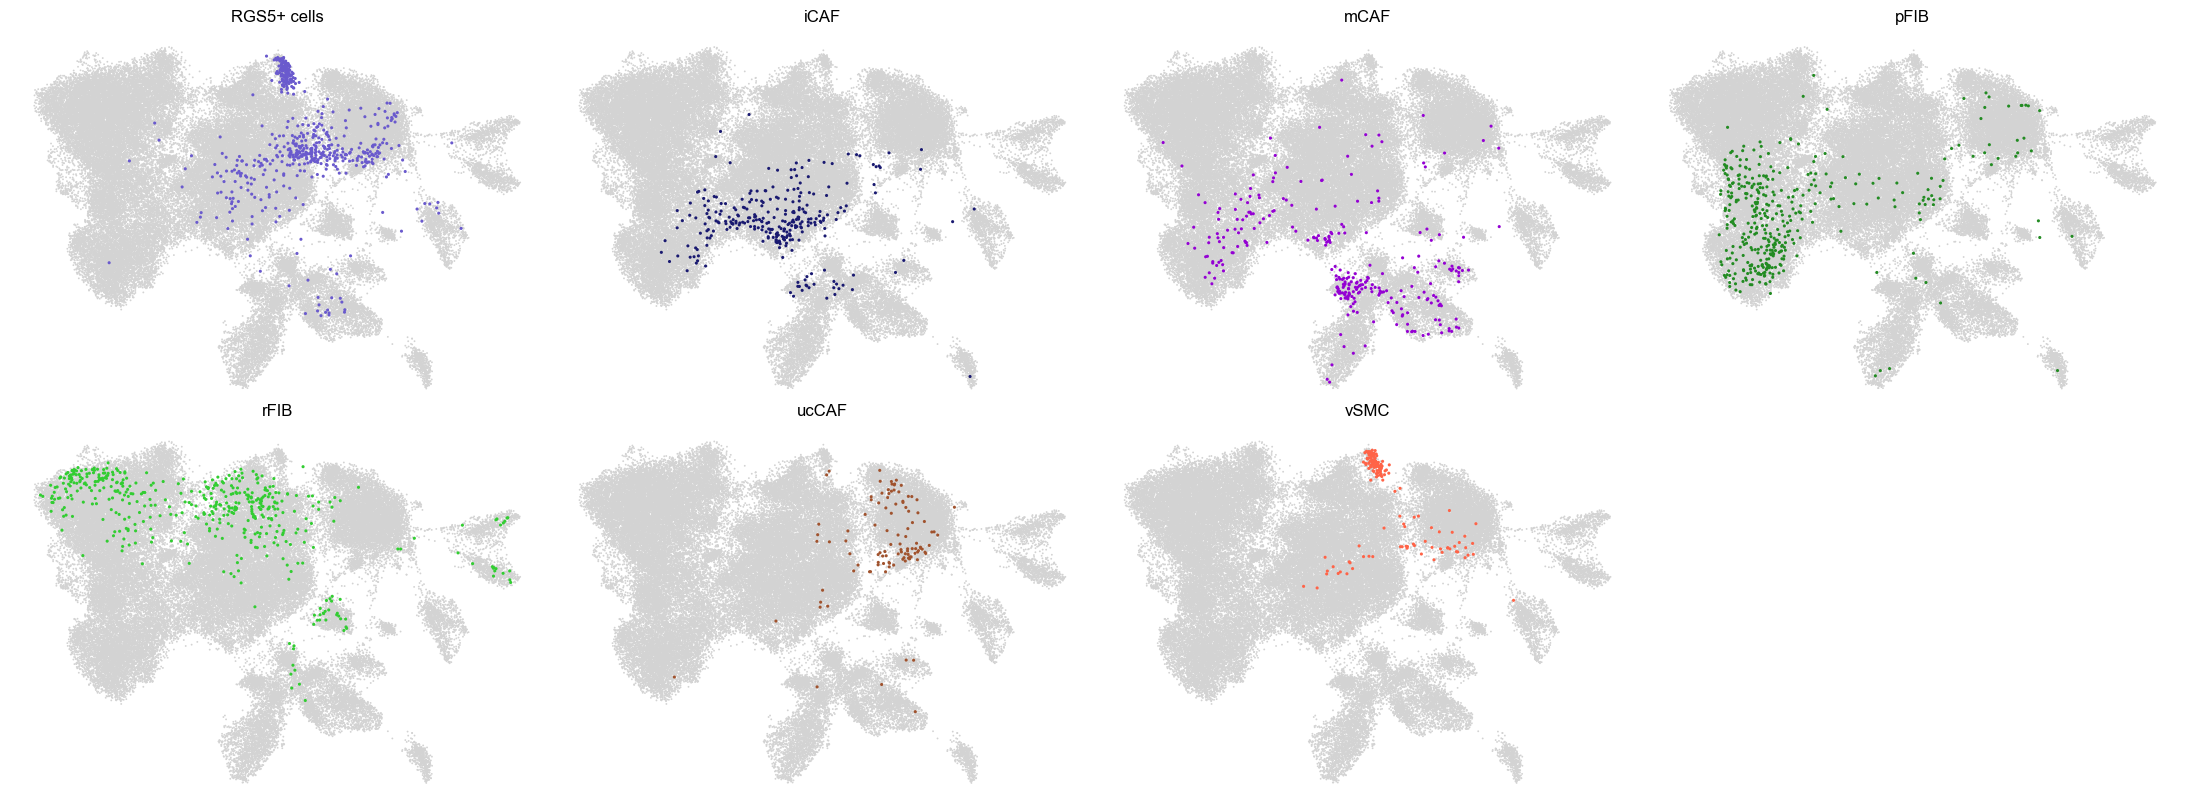

In [35]:
clusters = natsorted(que_data.obs['author_cell_type_3'].unique())
fig, axes = initialize_subplots(len(clusters), ncols = 4, gridspec_kw = dict(wspace = 0.02, hspace = 0.05))

basis = 'X_umap_2_imbalance'

for ix, cl in enumerate(clusters):
    ax = axes.flatten()[ix]

    sc.pl.embedding(fib_data, basis = basis, ax = ax, show = False, frameon = False, s = 7)
    sc.pl.umap(que_data[que_data.obs['author_cell_type_3']==cl], color = 'author_cell_type_3', ax = ax, show = False, frameon = False, s = 20, palette = cmap, legend_loc = None, title = cl)
    for coll in ax.collections:
        if isinstance(coll, mpl.collections.PathCollection):
            coll.set_rasterized(True)

[ax.set_visible(False) for ax in axes.flatten()[ix+1:]]

fig.savefig(os.path.join(fig_path, 'UMAP_CAFs_knn_CAF_clusters_individual_plots.pdf'), bbox_inches = 'tight', dpi = 600)

## Fig 6m

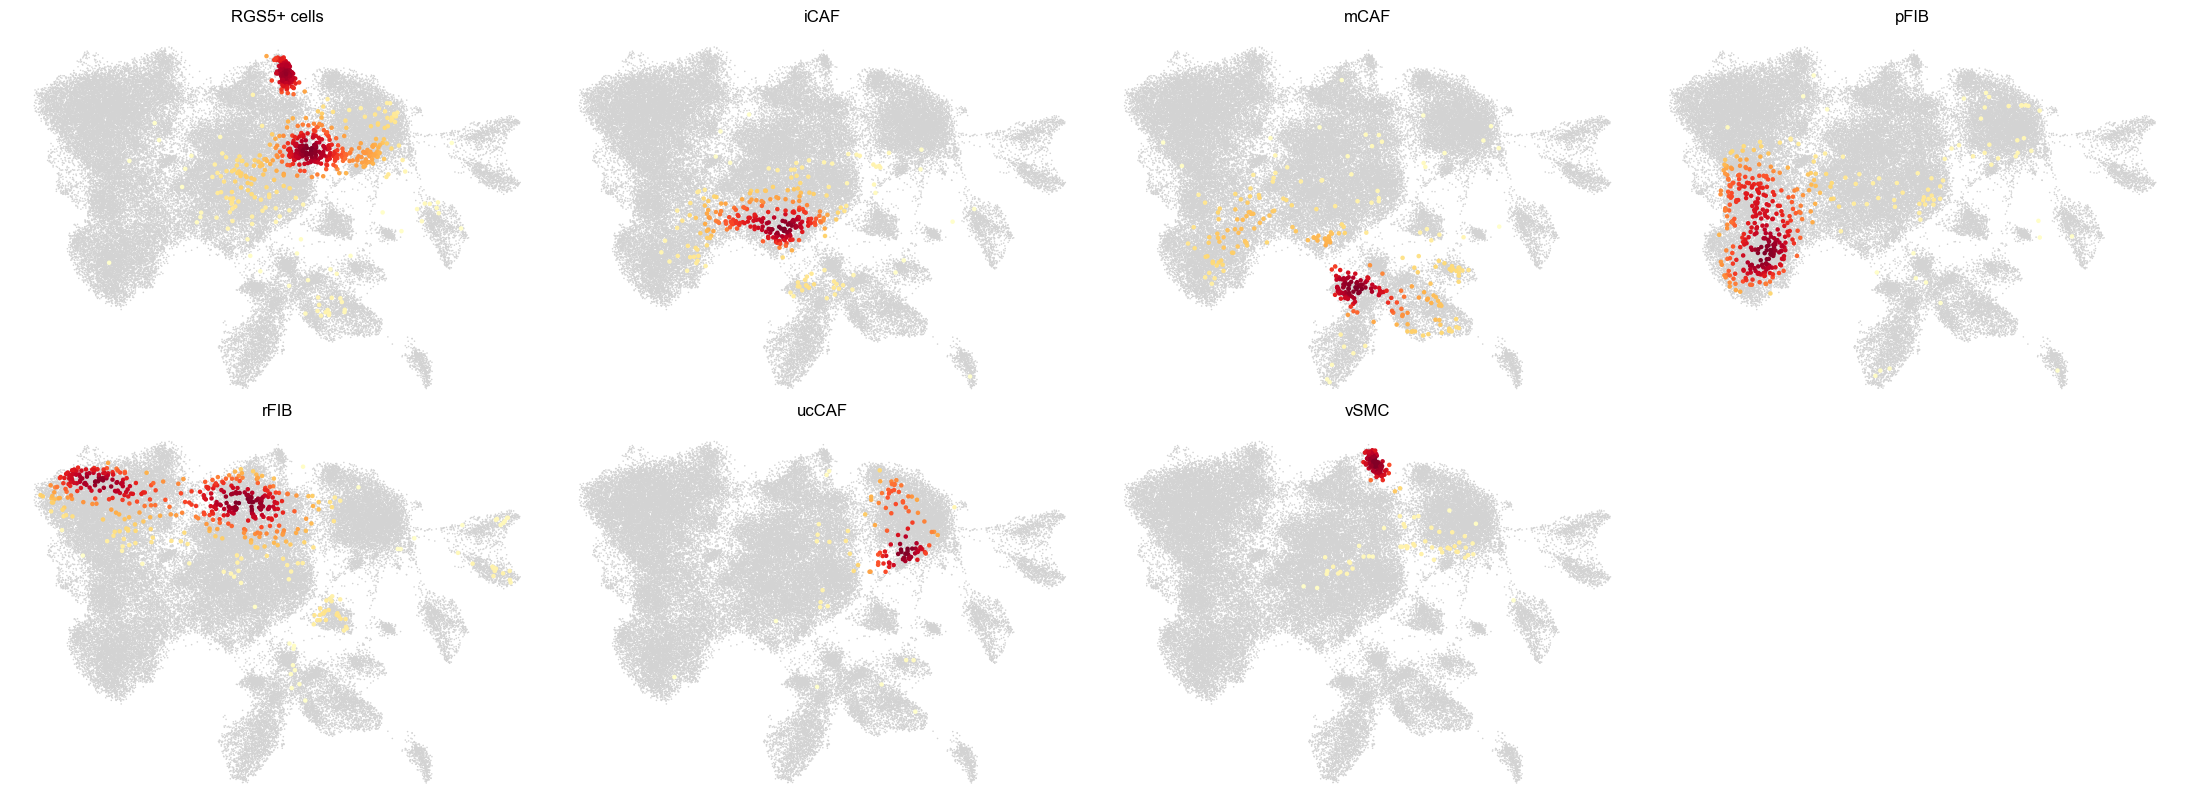

In [33]:
clusters = natsorted(que_data.obs['author_cell_type_3'].unique())
fig, axes = initialize_subplots(len(clusters), ncols = 4, gridspec_kw = dict(wspace = 0.02, hspace = 0.05))

basis = 'X_umap_2_imbalance'

for ix, cl in enumerate(clusters):
    ax = axes.flatten()[ix]

    sc.pl.embedding(fib_data, basis = basis, ax = ax, show = False, frameon = False, s = 5)
    
    x, y = zip(*que_data[que_data.obs['author_cell_type_3']==cl].obsm['X_umap'])
    #sc.pl.umap(, color = 'author_cell_type_3', ax = ax, show = False, frameon = False, s = 20, palette = cmap, legend_loc = None, title = cl)
    z = calc_density(x, y)
    ax.scatter(x, y, c = z, cmap = 'YlOrRd', s = 5)
    ax.set_title(cl)
    for coll in ax.collections:
        if isinstance(coll, mpl.collections.PathCollection):
            coll.set_rasterized(True)

[ax.set_visible(False) for ax in axes.flatten()[ix+1:]]

fig.savefig(os.path.join(fig_path, 'UMAP_CAFs_knn_CAF_clusters_embedding_density.pdf'), bbox_inches = 'tight', dpi = 600)

## Fig S6n

<Axes: title={'center': 'Annotation_Level_2_renumber'}, xlabel='UMAP1', ylabel='UMAP2'>

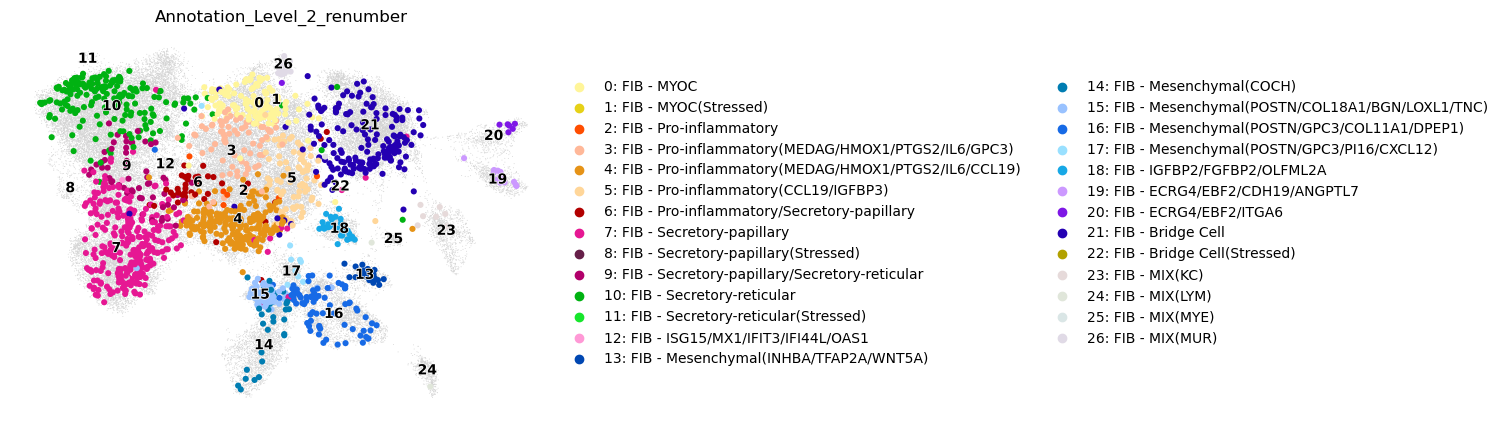

In [44]:
#basis = 'X_umap_2_imbalance'
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.umap(ref_data, ax = ax, show = False, frameon = False)
sc.pl.umap(que_data, color = 'Annotation_Level_2_FULL', ax = ax, show = False, frameon = False, palette = cmap)
sc.pl.umap(ref_data, color = 'Annotation_Level_2_renumber', ax = ax, show = False, frameon = False, s = 0, legend_loc = 'on data', legend_fontoutline=True)

## Fig 6l

In [189]:
cmap = {
    "vSMC": "tomato",
    "RGS5+ cells": "slateblue",
    "ucCAF": "sienna",
    "iCAF": "midnightblue",
    "mCAF": "darkviolet",
    "pFIB": "forestgreen",
    "rFIB": "limegreen",
}

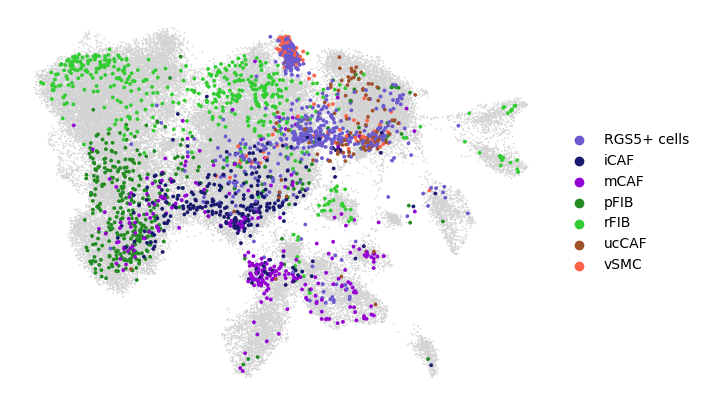

In [266]:
#basis = 'X_umap_2_imbalance'
fig, ax = plt.subplots(figsize = (7, 5))
sc.pl.umap(ref_data, ax = ax, show = False, frameon = False, s = 5)
sc.pl.umap(que_data, color = 'author_cell_type_3', ax = ax, show = False, frameon = False, s = 30, palette = cmap, title = '')
#sc.pl.umap(ref_data, color = 'Annotation_Level_2_renumber', ax = ax, show = False, frameon = False, s = 0, legend_loc = 'on data', legend_fontoutline=True)

fig.savefig(os.path.join(fig_path, 'UMAP_knn_Forsthuber_on_iHSCA_caf_clusters.png'), bbox_inches = 'tight', dpi = 1200)

## Fig S6o

[None, None]

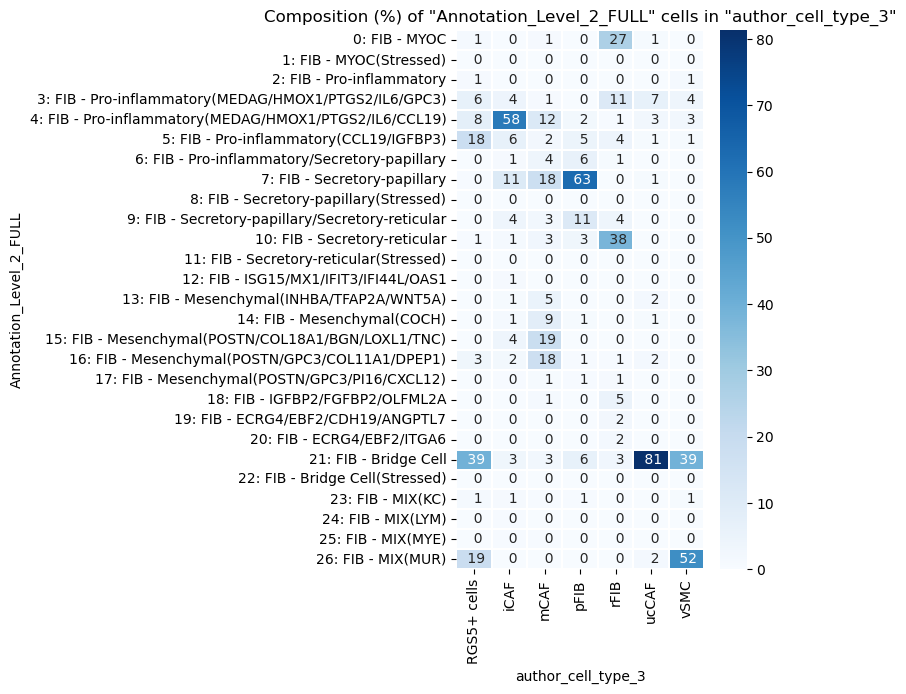

In [261]:
fig, ax = plt.subplots(figsize = (4, 7))
plot_group_composition_heatmap(que_data.obs, groupby_name='author_cell_type_3', count_group_name='Annotation_Level_2_FULL', cmap = 'Blues', ax = ax, fmt = '3.0f', transpose = True, lw = 0.1)
clear_output()
[fig.savefig(os.path.join(fig_path, f'Confusion_matrix_knn_Forsthuber_onto_iHSCA.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]